Реализация градиентного метода с шагом Поляка и сравнение с градиентным методом с постоянным шагом и правилом Армихо

Optimal point x_star: [0.17391304 0.95652174]
Optimal function value f_star: -1.0435e+00

--- Running Gradient Descent with Constant Step ---
  Iter  20: f(x) = -1.0435e+00, ||grad|| = 1.82e-05, alpha = 2.50e-01
Converged at iteration 21 (gradient norm 5.53e-06 below tolerance 1.00e-05).

--- Running Gradient Descent with Polyak Step ---
Converged at iteration 18 (gradient norm 8.02e-06 below tolerance 1.00e-05).

--- Running Gradient Descent with Armijo Step ---
  Iter  20: f(x) = -1.0435e+00, ||grad|| = 1.15e-04, alpha = 5.00e-01
Converged at iteration 24 (gradient norm 9.22e-06 below tolerance 1.00e-05).


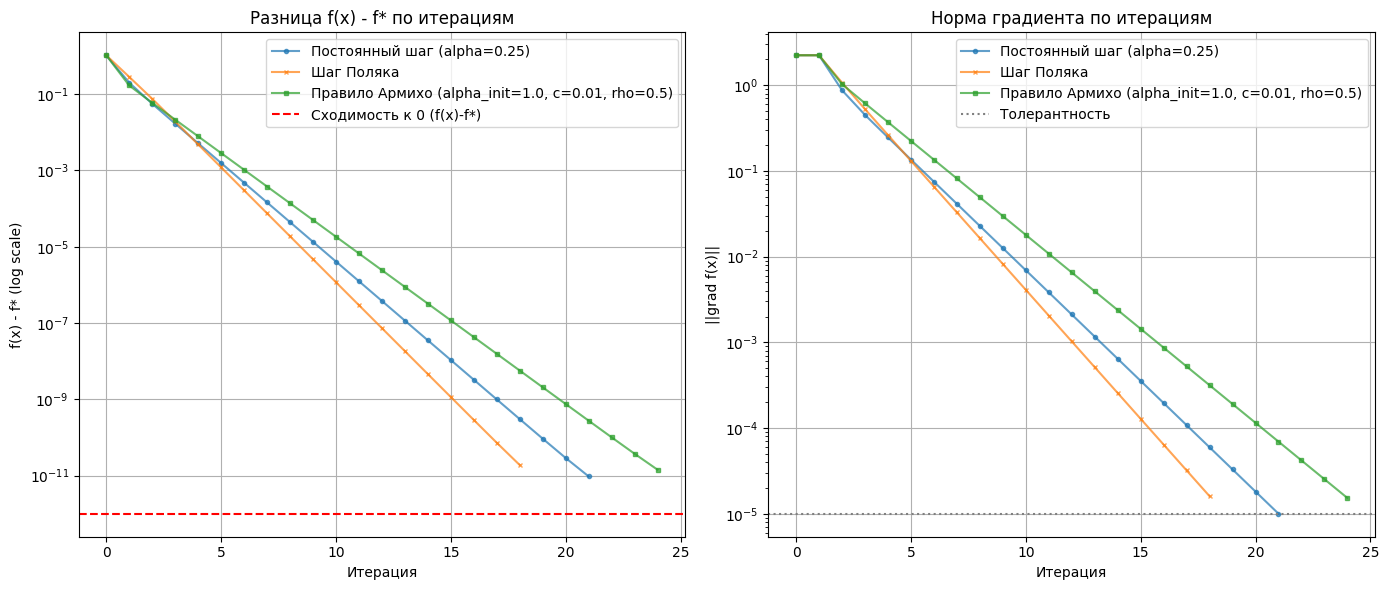

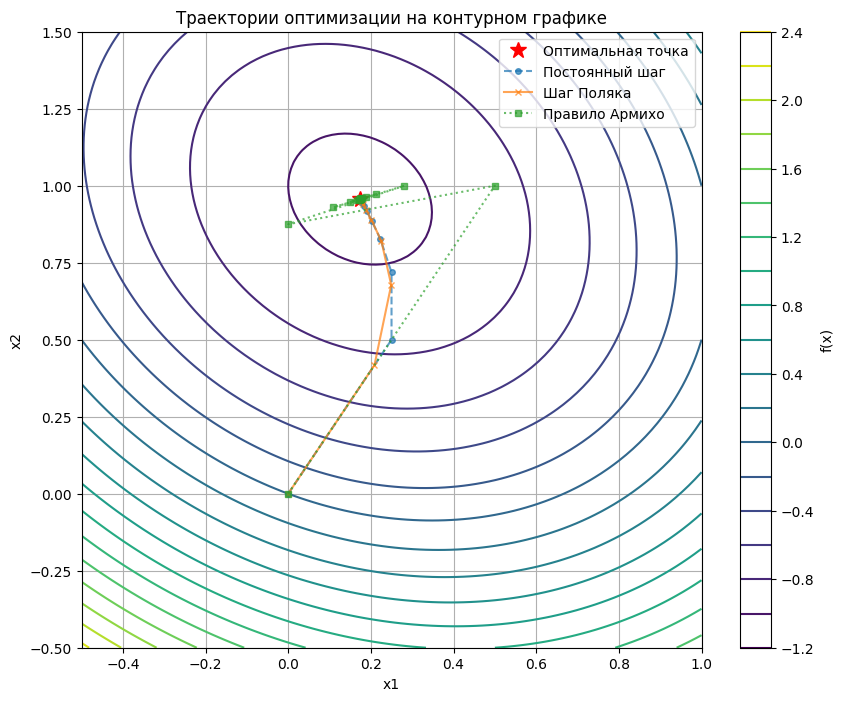

In [4]:

import numpy as np
import matplotlib.pyplot as plt

# 1. Определение целевой функции и ее градиента
class QuadraticObjective:
    def __init__(self, H, c):
        self.H = H
        self.c = c
        # Вычисляем оптимальные x_star и f_star для шага Поляка и сравнения
        self.x_star = -np.linalg.solve(self.H, self.c)
        self.f_star = 0.5 * self.x_star @ self.H @ self.x_star + self.c @ self.x_star

    def f(self, x):
        """Вычисляет значение функции."""
        return 0.5 * x @ self.H @ x + self.c @ x

    def grad_f(self, x):
        """Вычисляет градиент функции."""
        return self.H @ x + self.c

    def get_optimal_value(self):
        """Возвращает оптимальное значение функции f_star."""
        return self.f_star

    def get_optimal_point(self):
        """Возвращает оптимальную точку x_star."""
        return self.x_star

# 2. Реализация градиентного спуска с различными стратегиями шага
def gradient_descent(objective, x_init, max_iter, tol, step_strategy, strategy_params=None):
    """
    Реализует градиентный спуск с различными стратегиями выбора шага.

    Аргументы:
        objective: Объект, реализующий методы f(x) и grad_f(x).
        x_init: Начальная точка (np.array).
        max_iter: Максимальное количество итераций.
        tol: Толерантность для нормы градиента (критерий остановки).
        step_strategy: Строка, определяющая стратегию шага ("constant", "polyak", "armijo").
        strategy_params: Словарь параметров для выбранной стратегии шага.

    Возвращает:
        x: Найденная оптимальная точка.
        history: Словарь с историей значений x, f(x), норм градиента и размеров шага.
    """
    if strategy_params is None:
        strategy_params = {}

    x = np.copy(x_init)
    history = {'x': [x.copy()], 'f_val': [objective.f(x)], 'grad_norm': [np.linalg.norm(objective.grad_f(x))], 'steps': []}

    print(f"\n--- Running Gradient Descent with {step_strategy.capitalize()} Step ---")

    for i in range(max_iter):
        grad = objective.grad_f(x)
        grad_norm_sq = np.sum(grad**2)

        if grad_norm_sq < tol**2:
            print(f"Converged at iteration {i} (gradient norm {np.sqrt(grad_norm_sq):.2e} below tolerance {tol:.2e}).")
            break

        alpha = 0.0

        if step_strategy == "constant":
            alpha = strategy_params.get("alpha", 0.01) # Значение по умолчанию, если не указано
        elif step_strategy == "polyak":
            f_star = objective.get_optimal_value()
            current_f_val = objective.f(x)
            # Избегаем деления на ноль, если градиент уже нулевой
            # Также, если f(x) уже <= f_star, шаг может быть отрицательным или около нуля
            if grad_norm_sq == 0 or current_f_val <= f_star:
                alpha = 0
            else:
                alpha = (current_f_val - f_star) / grad_norm_sq

            # Добавим небольшую проверку на слишком маленький или отрицательный шаг,
            # что может произойти из-за численных неточностей, если f(x) очень близко к f_star
            if alpha < 1e-10:
                alpha = 0
        elif step_strategy == "armijo":
            alpha_init = strategy_params.get("alpha_init", 1.0)
            c = strategy_params.get("c", 0.01)
            rho = strategy_params.get("rho", 0.5)

            alpha = alpha_init
            # Условие Армихо: f(x_k - alpha * grad) <= f(x_k) - c * alpha * ||grad(x_k)||^2
            f_x_current = objective.f(x) # Вычисляем один раз
            while objective.f(x - alpha * grad) > f_x_current - c * alpha * grad_norm_sq:
                alpha *= rho
                if alpha < 1e-12: # Для предотвращения слишком малых шагов и зацикливания
                    # print(f"Armijo: alpha became too small at iteration {i}. Breaking line search.")
                    alpha = 0 # Устанавливаем в 0, чтобы остановить GD
                    break
        else:
            raise ValueError(f"Unknown step_strategy: {step_strategy}")

        if alpha == 0: # Если шаг стал нулевым, прекращаем итерации
            print(f"Alpha became zero at iteration {i}. Stopping.")
            break

        x_new = x - alpha * grad
        x = x_new

        history['x'].append(x.copy())
        history['f_val'].append(objective.f(x))
        history['grad_norm'].append(np.linalg.norm(grad))
        history['steps'].append(alpha)

        if (i + 1) % 20 == 0 or i == max_iter - 1:
            print(f"  Iter {i+1:3d}: f(x) = {history['f_val'][-1]:.4e}, ||grad|| = {history['grad_norm'][-1]:.2e}, alpha = {alpha:.2e}")


    if grad_norm_sq >= tol**2:
        print(f"Did not converge within {max_iter} iterations (gradient norm: {np.sqrt(grad_norm_sq):.2e}).")

    return x, history

# 3. Настройка и запуск сравнения
if __name__ == "__main__":
    # Определяем квадратичную целевую функцию
    # H должна быть симметричной и положительно определенной для выпуклости
    H = np.array([[3.0, 0.5],
                  [0.5, 2.0]])
    c = np.array([-1.0, -2.0])
    objective = QuadraticObjective(H, c)

    x_init = np.array([0.0, 0.0]) # Начальная точка
    max_iter = 200                # Максимальное количество итераций
    tol = 1e-5                    # Толерантность для нормы градиента
    epsilon_for_log_plot = 1e-12  # Малое число для стабильности логарифмирования (f(x) - f_star)

    print(f"Optimal point x_star: {objective.get_optimal_point()}")
    print(f"Optimal function value f_star: {objective.get_optimal_value():.4e}")

    # --- Метод с постоянным шагом ---
    # Для квадратичных функций шаг alpha должен быть < 2/L, где L - наибольшее собственное число H.
    # Собственные числа H: np.linalg.eigvals(H) -> [3.18, 1.81]. L = 3.18.
    # Так что alpha должно быть < 2/3.18 ~ 0.63. Выберем поменьше для стабильности.
    constant_alpha = 0.25 # Попробуйте 0.1 (медленно), 0.01 (очень медленно), 0.5 (быстро, но близко к краю стабильности)
    x_const, hist_const = gradient_descent(objective, x_init, max_iter, tol,
                                            "constant", {"alpha": constant_alpha})

    # --- Метод с шагом Поляка ---
    x_polyak, hist_polyak = gradient_descent(objective, x_init, max_iter, tol,
                                             "polyak", {})

    # --- Метод с правилом Армихо ---
    armijo_alpha_init = 1.0 # Начальный пробный шаг (может быть 1, 0.5, или даже 10)
    armijo_c = 0.01         # Коэффициент "достаточного" уменьшения
    armijo_rho = 0.5        # Коэффициент уменьшения шага
    x_armijo, hist_armijo = gradient_descent(objective, x_init, max_iter, tol,
                                             "armijo", {"alpha_init": armijo_alpha_init,
                                                         "c": armijo_c,
                                                         "rho": armijo_rho})

    # 4. Визуализация и сравнение результатов

    # 4.1. Сравнение значения функции по итерациям (отображаем f(x) - f_star)
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    # Вычисляем разницу f(x) - f_star и добавляем epsilon для логарифмической шкалы
    f_star = objective.get_optimal_value()
    plt.plot(np.array(hist_const['f_val']) - f_star + epsilon_for_log_plot,
             label=f'Постоянный шаг (alpha={constant_alpha})', marker='o', markersize=3, alpha=0.7)
    plt.plot(np.array(hist_polyak['f_val']) - f_star + epsilon_for_log_plot,
             label='Шаг Поляка', marker='x', markersize=3, alpha=0.7)
    plt.plot(np.array(hist_armijo['f_val']) - f_star + epsilon_for_log_plot,
             label=f'Правило Армихо (alpha_init={armijo_alpha_init}, c={armijo_c}, rho={armijo_rho})',
             marker='s', markersize=3, alpha=0.7)

    # Вместо axhline для f*, теперь показываем уровень 0 (или epsilon) для разницы
    plt.axhline(y=epsilon_for_log_plot, color='r', linestyle='--', label='Сходимость к 0 (f(x)-f*)')
    plt.title('Разница f(x) - f* по итерациям')
    plt.xlabel('Итерация')
    plt.ylabel('f(x) - f* (log scale)')
    plt.yscale('log') # Теперь логарифмическая шкала должна работать без предупреждений
    plt.legend()
    plt.grid(True)

    # 4.2. Сравнение нормы градиента по итерациям
    plt.subplot(1, 2, 2)
    plt.plot(hist_const['grad_norm'], label=f'Постоянный шаг (alpha={constant_alpha})', marker='o', markersize=3, alpha=0.7)
    plt.plot(hist_polyak['grad_norm'], label='Шаг Поляка', marker='x', markersize=3, alpha=0.7)
    plt.plot(hist_armijo['grad_norm'], label=f'Правило Армихо (alpha_init={armijo_alpha_init}, c={armijo_c}, rho={armijo_rho})', marker='s', markersize=3, alpha=0.7)
    plt.axhline(y=tol, color='gray', linestyle=':', label='Толерантность')
    plt.title('Норма градиента по итерациям')
    plt.xlabel('Итерация')
    plt.ylabel('||grad f(x)||')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 4.3. Траектории оптимизации на контурном графике (только для 2D)
    if x_init.size == 2:
        # Устанавливаем разумные границы для графика, включая начальную, оптимальную точки и траектории
        all_x_coords = [x[0] for hist in [hist_const, hist_polyak, hist_armijo] for x in hist['x']]
        all_y_coords = [x[1] for hist in [hist_const, hist_polyak, hist_armijo] for x in hist['x']]

        x1_min = min(all_x_coords + [objective.x_star[0], x_init[0]]) - 0.5
        x1_max = max(all_x_coords + [objective.x_star[0], x_init[0]]) + 0.5
        x2_min = min(all_y_coords + [objective.x_star[1], x_init[1]]) - 0.5
        x2_max = max(all_y_coords + [objective.x_star[1], x_init[1]]) + 0.5

        x1_grid = np.linspace(x1_min, x1_max, 100)
        x2_grid = np.linspace(x2_min, x2_max, 100)
        X1, X2 = np.meshgrid(x1_grid, x2_grid)
        Z = np.array([objective.f(np.array([x, y])) for x, y in zip(np.ravel(X1), np.ravel(X2))]).reshape(X1.shape)

        plt.figure(figsize=(10, 8))
        plt.contour(X1, X2, Z, levels=20, cmap='viridis')
        plt.colorbar(label='f(x)')
        plt.plot(objective.x_star[0], objective.x_star[1], 'r*', markersize=12, label='Оптимальная точка')

        path_const = np.array(hist_const['x'])
        path_polyak = np.array(hist_polyak['x'])
        path_armijo = np.array(hist_armijo['x'])

        plt.plot(path_const[:, 0], path_const[:, 1], 'o--', label='Постоянный шаг', markersize=4, alpha=0.7)
        plt.plot(path_polyak[:, 0], path_polyak[:, 1], 'x-', label='Шаг Поляка', markersize=4, alpha=0.7)
        plt.plot(path_armijo[:, 0], path_armijo[:, 1], 's:', label='Правило Армихо', markersize=4, alpha=0.7)

        plt.title('Траектории оптимизации на контурном графике')
        plt.xlabel('x1')
        plt.ylabel('x2')
        plt.legend()
        plt.grid(True)
        plt.show()
